# Round 1 Log Viewer

This notebook loads `logs/round1/269717.log`, reconstructs your submission fills, and surfaces performance insights with graphs for PnL, inventory, execution quality, and market context.

If you want to inspect another run later, just change `LOG_PATH` in the first code cell.

In [1]:
from __future__ import annotations

import json
import os
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'logs').exists():
            return candidate
    raise FileNotFoundError('Could not find the repo root from the current working directory.')


REPO_ROOT = find_repo_root()
MPLCONFIGDIR = REPO_ROOT / '.mpl-cache'
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.options.display.float_format = '{:,.2f}'.format

LOG_PATH = REPO_ROOT / 'logs' / 'round1' / '269717.log'
MARKOUT_HORIZON_MS = 1_000
POSITION_LIMIT = 80

print(f'Repo root: {REPO_ROOT}')
print(f'Log path:  {LOG_PATH}')


Repo root: /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4
Log path:  /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4/logs/round1/269717.log


In [2]:
def load_round_log(log_path: Path) -> tuple[dict, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    raw = json.loads(log_path.read_text())

    activity = pd.read_csv(StringIO(raw['activitiesLog']), sep=';')
    activity.columns = [column.strip() for column in activity.columns]
    for column in activity.columns:
        if column != 'product':
            activity[column] = pd.to_numeric(activity[column], errors='coerce')
    activity['spread'] = activity['ask_price_1'] - activity['bid_price_1']
    bid_vol = activity['bid_volume_1'].fillna(0)
    ask_vol = activity['ask_volume_1'].fillna(0)
    total_top_level = (bid_vol + ask_vol).replace(0, np.nan)
    activity['book_imbalance'] = (bid_vol - ask_vol) / total_top_level
    activity['time_s'] = activity['timestamp'] / 1000

    trades = pd.DataFrame(raw['tradeHistory'])
    for column in ['timestamp', 'price', 'quantity', 'buyer', 'seller', 'symbol', 'currency']:
        if column not in trades.columns:
            trades[column] = pd.Series(dtype='float64' if column in {'timestamp', 'price', 'quantity'} else 'object')
    trades = trades.sort_values('timestamp').reset_index(drop=True)
    trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
    trades['price'] = pd.to_numeric(trades['price'], errors='coerce')
    trades['quantity'] = pd.to_numeric(trades['quantity'], errors='coerce')
    trades['is_submission'] = (trades['buyer'] == 'SUBMISSION') | (trades['seller'] == 'SUBMISSION')
    trades['side'] = np.select(
        [trades['buyer'] == 'SUBMISSION', trades['seller'] == 'SUBMISSION'],
        [1, -1],
        default=0,
    )
    trades['side_label'] = trades['side'].map({1: 'BUY', -1: 'SELL', 0: 'OTHER'})
    trades['signed_qty'] = trades['side'] * trades['quantity']
    trades['notional'] = trades['price'] * trades['quantity']
    trades['cash_flow'] = -trades['side'] * trades['notional']

    log_entries = pd.DataFrame(raw['logs'])
    for column in ['timestamp', 'lambdaLog', 'sandboxLog']:
        if column not in log_entries.columns:
            log_entries[column] = pd.Series(dtype='object')

    return raw, activity, trades, log_entries


def build_views(
    activity: pd.DataFrame,
    trades: pd.DataFrame,
    markout_horizon_ms: int = 1_000,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame], dict[str, pd.DataFrame], pd.DataFrame]:
    submission_trades = trades[trades['is_submission']].copy()
    submission_trades = submission_trades.sort_values(['symbol', 'timestamp', 'price']).reset_index(drop=True)
    submission_trades['buy_qty'] = np.where(submission_trades['side'] == 1, submission_trades['quantity'], 0)
    submission_trades['sell_qty'] = np.where(submission_trades['side'] == -1, submission_trades['quantity'], 0)

    product_views: dict[str, pd.DataFrame] = {}
    trade_views: dict[str, pd.DataFrame] = {}

    for product, market in activity.groupby('product', sort=True):
        market = market.sort_values('timestamp').copy()
        product_trades = submission_trades[submission_trades['symbol'] == product].copy()

        market_lookup = market[['timestamp', 'mid_price', 'spread']].rename(columns={'mid_price': 'mid_at_trade'})
        future_lookup = market[['timestamp', 'mid_price']].rename(columns={'mid_price': 'future_mid'})
        future_lookup['timestamp'] = future_lookup['timestamp'] - markout_horizon_ms

        if not product_trades.empty:
            product_trades = product_trades.merge(market_lookup, on='timestamp', how='left')
            product_trades = product_trades.merge(future_lookup, on='timestamp', how='left')
            product_trades['fill_edge'] = np.where(
                product_trades['side'] == 1,
                product_trades['mid_at_trade'] - product_trades['price'],
                product_trades['price'] - product_trades['mid_at_trade'],
            )
            product_trades['markout'] = np.where(
                product_trades['side'] == 1,
                product_trades['future_mid'] - product_trades['price'],
                product_trades['price'] - product_trades['future_mid'],
            )

            trade_by_time = product_trades.groupby('timestamp', as_index=False).agg(
                signed_qty=('signed_qty', 'sum'),
                traded_qty=('quantity', 'sum'),
                turnover=('notional', 'sum'),
                buy_qty=('buy_qty', 'sum'),
                sell_qty=('sell_qty', 'sum'),
            )
            market = market.merge(trade_by_time, on='timestamp', how='left')

        for column in ['signed_qty', 'traded_qty', 'turnover', 'buy_qty', 'sell_qty']:
            if column not in market.columns:
                market[column] = 0.0
            market[column] = market[column].fillna(0.0)

        market['position'] = market['signed_qty'].cumsum()
        market['running_peak_pnl'] = market['profit_and_loss'].cummax()
        market['drawdown'] = market['running_peak_pnl'] - market['profit_and_loss']

        product_views[product] = market
        trade_views[product] = product_trades

    pnl_by_product = activity.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
    pnl_by_product['TOTAL'] = pnl_by_product.sum(axis=1)
    return submission_trades, product_views, trade_views, pnl_by_product


def build_summary(
    product_views: dict[str, pd.DataFrame],
    trade_views: dict[str, pd.DataFrame],
    pnl_by_product: pd.DataFrame,
) -> tuple[pd.DataFrame, float, float]:
    summary_rows = []
    total_final_pnl = float(pnl_by_product['TOTAL'].iloc[-1])
    total_drawdown = float((pnl_by_product['TOTAL'].cummax() - pnl_by_product['TOTAL']).max())

    for product, market in product_views.items():
        product_trades = trade_views[product]
        final_pnl = float(market['profit_and_loss'].iloc[-1])
        final_position = float(market['position'].iloc[-1])
        final_mid = float(market['mid_price'].iloc[-1])

        inventory_pnl_proxy = np.nan
        if not product_trades.empty:
            inventory_pnl_proxy = float(product_trades['cash_flow'].sum() + final_position * final_mid)

        summary_rows.append(
            {
                'product': product,
                'final_pnl': final_pnl,
                'pnl_share_pct': 100 * final_pnl / total_final_pnl if total_final_pnl else np.nan,
                'max_drawdown': float(market['drawdown'].max()),
                'mid_move': float(market['mid_price'].iloc[-1] - market['mid_price'].iloc[0]),
                'avg_spread': float(market['spread'].mean()),
                'trade_count': int(len(product_trades)),
                'turnover': float(product_trades['notional'].sum()),
                'buy_qty': float(product_trades.loc[product_trades['side'] == 1, 'quantity'].sum()),
                'sell_qty': float(product_trades.loc[product_trades['side'] == -1, 'quantity'].sum()),
                'final_position': final_position,
                'min_position': float(market['position'].min()),
                'max_position': float(market['position'].max()),
                'avg_fill_edge': float(product_trades['fill_edge'].mean()) if not product_trades.empty else np.nan,
                'avg_markout': float(product_trades['markout'].mean()) if not product_trades.empty else np.nan,
                'inventory_pnl_proxy': inventory_pnl_proxy,
            }
        )

    summary = pd.DataFrame(summary_rows).sort_values('final_pnl', ascending=False).reset_index(drop=True)
    return summary, total_final_pnl, total_drawdown


def generate_insights(
    summary: pd.DataFrame,
    product_views: dict[str, pd.DataFrame],
    trade_views: dict[str, pd.DataFrame],
    markout_horizon_ms: int,
) -> list[str]:
    insights: list[str] = []
    winner = summary.iloc[0]
    runner = summary.iloc[1] if len(summary) > 1 else None

    insights.append(
        f"Total PnL finished at {summary['final_pnl'].sum():,.2f}. "
        f"{winner['product']} contributed {winner['pnl_share_pct']:.1f}% of that result."
    )

    if runner is not None:
        insights.append(
            f"{winner['product']} outperformed {runner['product']} by "
            f"{winner['final_pnl'] - runner['final_pnl']:,.2f}."
        )

    for _, row in summary.iterrows():
        product = row['product']
        product_trades = trade_views[product]

        if row['trade_count'] == 0:
            insights.append(f'{product} had no submission fills in this run.')
            continue

        edge_text = 'positive' if pd.notna(row['avg_fill_edge']) and row['avg_fill_edge'] > 0 else 'negative'
        markout_text = 'positive' if pd.notna(row['avg_markout']) and row['avg_markout'] > 0 else 'negative'
        limit_touched = abs(row['max_position']) >= POSITION_LIMIT or abs(row['min_position']) >= POSITION_LIMIT

        insights.append(
            f"{product}: {int(row['trade_count'])} submission fills, avg fill edge {row['avg_fill_edge']:.2f}, "
            f"and avg {markout_horizon_ms}ms markout {row['avg_markout']:.2f} "
            f"({edge_text} execution / {markout_text} short-term follow-through)."
        )

        if limit_touched:
            insights.append(
                f"{product} touched the {POSITION_LIMIT}-lot position limit and finished at {int(row['final_position'])}, "
                'so inventory carried a meaningful share of the result.'
            )

        if abs(row['mid_move']) > row['avg_spread'] * 10:
            direction = 'uptrend' if row['mid_move'] > 0 else 'downtrend'
            insights.append(
                f"{product} spent the session in a strong {direction}: mid-price moved {row['mid_move']:.1f} "
                f"against an average spread of {row['avg_spread']:.2f}."
            )

        if product_trades['side'].eq(1).all() or product_trades['side'].eq(-1).all():
            one_way = 'buying only' if product_trades['side'].eq(1).all() else 'selling only'
            insights.append(f'{product} was effectively {one_way}, so the run depended heavily on directional follow-through.')

    return insights


raw_log, activity, trades, log_entries = load_round_log(LOG_PATH)
submission_trades, product_views, trade_views, pnl_by_product = build_views(activity, trades, MARKOUT_HORIZON_MS)
annotated_submission_trades = pd.concat(trade_views.values(), ignore_index=True) if trade_views else submission_trades.copy()
if not annotated_submission_trades.empty:
    annotated_submission_trades = annotated_submission_trades.sort_values(['symbol', 'timestamp', 'price']).reset_index(drop=True)
summary, total_final_pnl, total_max_drawdown = build_summary(product_views, trade_views, pnl_by_product)

non_empty_debug = int(log_entries['lambdaLog'].fillna('').astype(bool).sum() + log_entries['sandboxLog'].fillna('').astype(bool).sum())

display(Markdown(
    f"""
### Loaded Run
- `submissionId`: `{raw_log['submissionId']}`
- Activity rows: `{len(activity):,}`
- Market trades: `{len(trades):,}`
- Submission trades: `{len(submission_trades):,}`
- Log entries: `{len(log_entries):,}`
- Total final PnL: `{total_final_pnl:,.2f}`
- Total max drawdown: `{total_max_drawdown:,.2f}`
- Non-empty debug logs: `{non_empty_debug}`
"""
))

summary.round(2)



### Loaded Run
- `submissionId`: `4686e2fd-2a5d-4fa4-9cda-04e2fb11a624`
- Activity rows: `20,000`
- Market trades: `1,155`
- Submission trades: `703`
- Log entries: `10,000`
- Total final PnL: `96,398.44`
- Total max drawdown: `1,268.75`
- Non-empty debug logs: `0`


,product,final_pnl,pnl_share_pct,max_drawdown,mid_move,avg_spread,trade_count,turnover,buy_qty,sell_qty,final_position,min_position,max_position,avg_fill_edge,avg_markout,inventory_pnl_proxy
0,INTARIAN_PEPPER_ROOT,"79,352.00",82.32,576.00,"1,001.00",15.19,7,"1,040,640.00",80.00,0.00,80.00,11.00,80.00,-7.86,-7.71,"79,320.00"
1,ASH_COATED_OSMIUM,"17,046.44",17.68,805.25,-6.00,16.18,696,"36,859,656.00","1,883.00","1,803.00",80.00,-80.00,80.00,2.07,3.89,"17,662.00"


In [3]:
insights = generate_insights(summary, product_views, trade_views, MARKOUT_HORIZON_MS)
display(Markdown('### Auto Insights\n' + '\n'.join(f'- {line}' for line in insights)))

display(Markdown('### Submission Trade Preview'))
annotated_submission_trades[
    ['timestamp', 'symbol', 'side_label', 'price', 'quantity', 'mid_at_trade', 'fill_edge', 'markout']
].head(20)


### Auto Insights
- Total PnL finished at 96,398.44. INTARIAN_PEPPER_ROOT contributed 82.3% of that result.
- INTARIAN_PEPPER_ROOT outperformed ASH_COATED_OSMIUM by 62,305.56.
- INTARIAN_PEPPER_ROOT: 7 submission fills, avg fill edge -7.86, and avg 1000ms markout -7.71 (negative execution / negative short-term follow-through).
- INTARIAN_PEPPER_ROOT touched the 80-lot position limit and finished at 80, so inventory carried a meaningful share of the result.
- INTARIAN_PEPPER_ROOT spent the session in a strong uptrend: mid-price moved 1001.0 against an average spread of 15.19.
- INTARIAN_PEPPER_ROOT was effectively buying only, so the run depended heavily on directional follow-through.
- ASH_COATED_OSMIUM: 696 submission fills, avg fill edge 2.07, and avg 1000ms markout 3.89 (positive execution / positive short-term follow-through).
- ASH_COATED_OSMIUM touched the 80-lot position limit and finished at 80, so inventory carried a meaningful share of the result.

### Submission Trade Preview

,timestamp,symbol,side_label,price,quantity,mid_at_trade,fill_edge,markout
0,100,ASH_COATED_OSMIUM,SELL,"10,000.00",15,"10,009.50",-9.50,-17.00
1,200,ASH_COATED_OSMIUM,SELL,"10,000.00",14,"10,009.50",-9.50,-17.00
2,300,ASH_COATED_OSMIUM,SELL,"10,000.00",15,"10,011.00",-11.00,-9.00
3,300,ASH_COATED_OSMIUM,SELL,"10,006.00",4,"10,011.00",-5.00,-3.00
4,900,ASH_COATED_OSMIUM,SELL,"10,001.00",12,"10,009.00",-8.00,-7.50
5,1000,ASH_COATED_OSMIUM,BUY,"10,000.00",3,"10,010.00",10.00,10.00
6,1000,ASH_COATED_OSMIUM,SELL,"10,001.00",14,"10,010.00",-9.00,-9.00
7,1300,ASH_COATED_OSMIUM,SELL,"10,001.00",9,"10,009.00",-8.00,-10.00
8,5600,ASH_COATED_OSMIUM,BUY,"9,999.00",8,"10,007.50",8.50,18.00
9,5700,ASH_COATED_OSMIUM,SELL,"10,001.00",8,"10,009.00",-8.00,-9.00


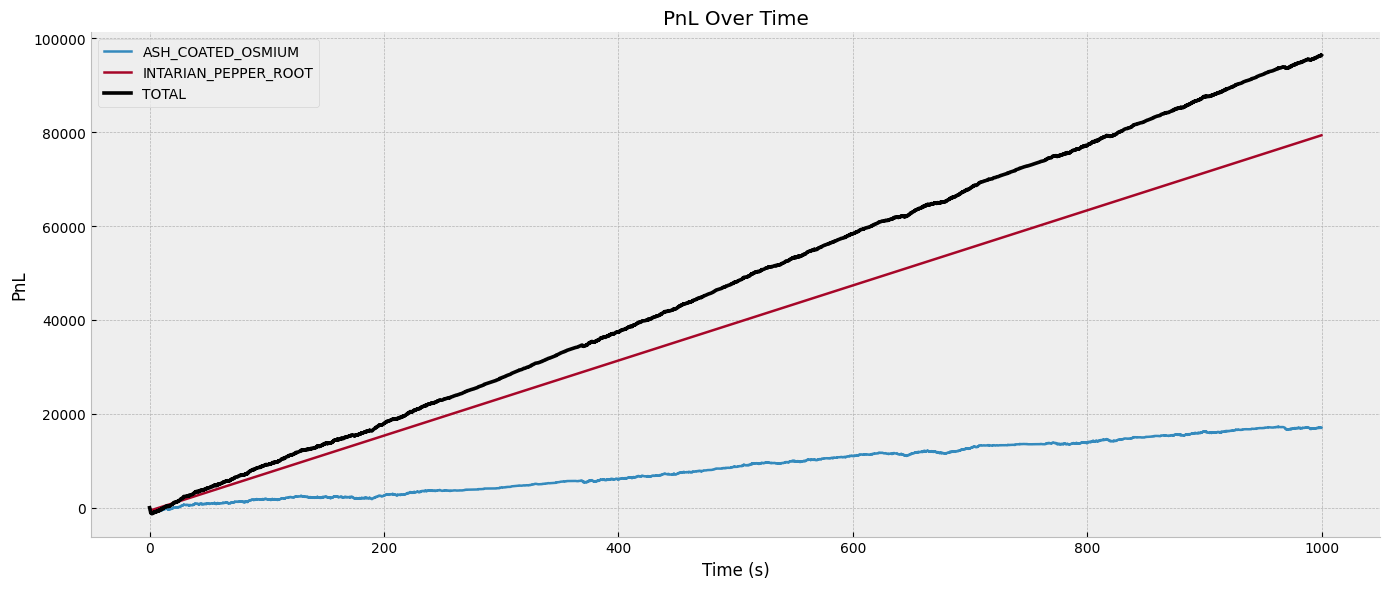

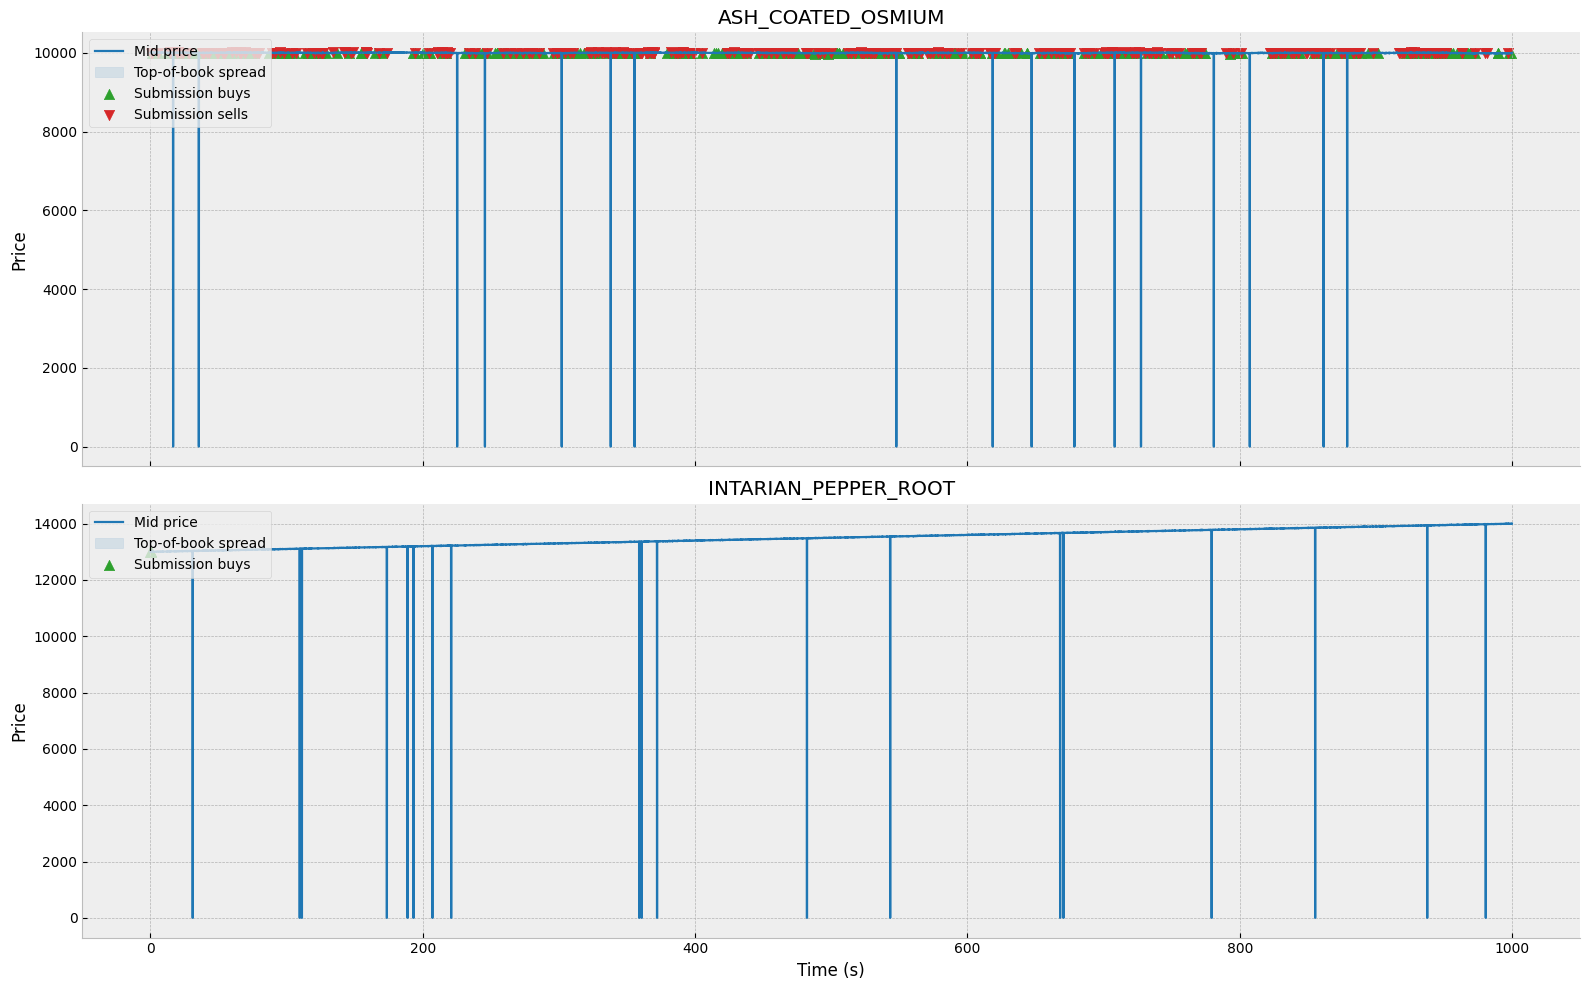

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
for column in [name for name in pnl_by_product.columns if name != 'TOTAL']:
    ax.plot(pnl_by_product.index / 1000, pnl_by_product[column], linewidth=1.8, label=column)
ax.plot(pnl_by_product.index / 1000, pnl_by_product['TOTAL'], color='black', linewidth=2.6, label='TOTAL')
ax.set_title('PnL Over Time')
ax.set_xlabel('Time (s)')
ax.set_ylabel('PnL')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

products = list(product_views)
fig, axes = plt.subplots(len(products), 1, figsize=(16, 5 * len(products)), sharex=True)
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    market = product_views[product]
    product_trades = trade_views[product]

    ax.plot(market['time_s'], market['mid_price'], color='tab:blue', linewidth=1.6, label='Mid price')
    ax.fill_between(
        market['time_s'],
        market['bid_price_1'],
        market['ask_price_1'],
        color='tab:blue',
        alpha=0.12,
        label='Top-of-book spread',
    )

    buys = product_trades[product_trades['side'] == 1]
    sells = product_trades[product_trades['side'] == -1]
    if not buys.empty:
        ax.scatter(buys['timestamp'] / 1000, buys['price'], color='tab:green', marker='^', s=55, label='Submission buys')
    if not sells.empty:
        ax.scatter(sells['timestamp'] / 1000, sells['price'], color='tab:red', marker='v', s=55, label='Submission sells')

    ax.set_title(product)
    ax.set_ylabel('Price')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


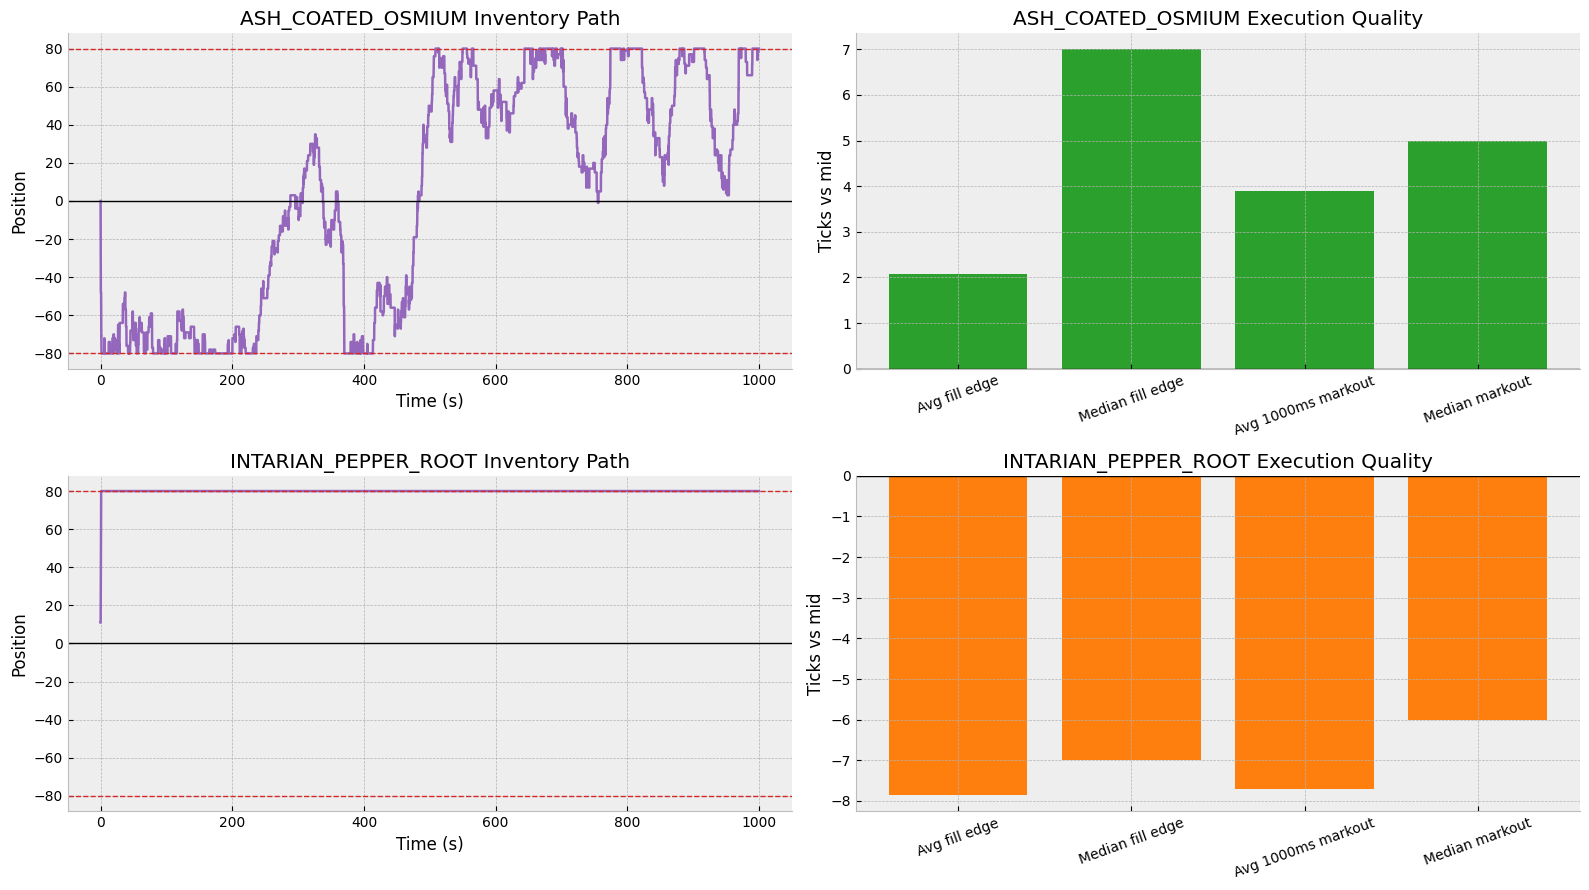

### Debug Logs
No non-empty `lambdaLog` or `sandboxLog` entries were present in this run.

In [5]:
fig, axes = plt.subplots(len(products), 2, figsize=(16, 4.5 * len(products)))
if len(products) == 1:
    axes = np.array([axes])

for row_index, product in enumerate(products):
    market = product_views[product]
    product_trades = trade_views[product]

    ax_position = axes[row_index, 0]
    ax_metrics = axes[row_index, 1]

    ax_position.plot(market['time_s'], market['position'], color='tab:purple', linewidth=1.8)
    ax_position.axhline(POSITION_LIMIT, color='tab:red', linestyle='--', linewidth=1)
    ax_position.axhline(-POSITION_LIMIT, color='tab:red', linestyle='--', linewidth=1)
    ax_position.axhline(0, color='black', linewidth=1)
    ax_position.set_title(f'{product} Inventory Path')
    ax_position.set_xlabel('Time (s)')
    ax_position.set_ylabel('Position')

    metric_names = [
        'Avg fill edge',
        'Median fill edge',
        f'Avg {MARKOUT_HORIZON_MS}ms markout',
        'Median markout',
    ]
    metric_values = [
        product_trades['fill_edge'].mean(),
        product_trades['fill_edge'].median(),
        product_trades['markout'].mean(),
        product_trades['markout'].median(),
    ]
    metric_values = [0 if pd.isna(value) else value for value in metric_values]
    metric_colors = ['tab:green' if value >= 0 else 'tab:orange' for value in metric_values]

    ax_metrics.bar(metric_names, metric_values, color=metric_colors)
    ax_metrics.axhline(0, color='black', linewidth=1)
    ax_metrics.set_title(f'{product} Execution Quality')
    ax_metrics.set_ylabel('Ticks vs mid')
    ax_metrics.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

if non_empty_debug:
    debug_view = log_entries.loc[
        log_entries['lambdaLog'].fillna('').astype(bool) | log_entries['sandboxLog'].fillna('').astype(bool),
        ['timestamp', 'lambdaLog', 'sandboxLog'],
    ]
    display(Markdown('### Non-empty Debug Logs'))
    display(debug_view.head(20))
else:
    display(Markdown('### Debug Logs\nNo non-empty `lambdaLog` or `sandboxLog` entries were present in this run.'))
